In [ ]:
import pandas as pd
import numpy as np

raw_df = pd.read_csv("../data/raw/Timely_and_Effective_Care-Hospital_NJ.csv")
# --- CELL 1: PREPARE CMS WQ DATA (OP_18b) ---
# Filter raw_df for NJ hospitals and the OP_18b measure (median wait time)
wq_data = raw_df[(raw_df['State'] == 'NJ') & (raw_df['Measure ID'] == 'OP_18b')].copy()

# Coerce 'Not Available' to NaN and drop missing values
wq_data['OP18b_minutes'] = pd.to_numeric(wq_data['Score'], errors='coerce')
wq_data = wq_data.dropna(subset=['OP18b_minutes'])

# Convert minutes to hours for consistency with arrival/service rates (Wq_hours)
wq_data['Wq_hours'] = wq_data['OP18b_minutes'] / 60.0

# Prepare for merge by standardizing names
wq_data['name_match'] = wq_data['Facility Name'].str.upper().str.strip()

print(f"Prepared {len(wq_data)} NJ hospitals with wait time data.")
display(wq_data[['Facility Name', 'Wq_hours']].head())

Prepared 60 NJ hospitals with wait time data.


/tmp/ipykernel_2492/1829123715.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv("Timely_and_Effective_Care-Hospital.csv")


,Facility Name,Wq_hours
78663,HACKENSACK UNIVERSITY MEDICAL CENTER,3.283333
78693,NEWARK BETH ISRAEL MEDICAL CENTER,2.816667
78723,PALISADES MEDICAL CENTER,3.450000
78753,HUNTERDON MEDICAL CENTER,3.866667
78783,ST MARY'S GENERAL HOSPITAL,3.050000


In [ ]:
import pandas as pd

# --- CELL 2: LAMBDA ESTIMATION (CLEANING NJSHAD EXPORT) ---
# MODELING ASSUMPTION: Since individual-hospital volume is not published,
# we disaggregate county-level patient residence data proportional to bed counts.

raw = pd.read_excel("../data/raw/njshad_county_ed_visits.xlsx", sheet_name="Sheet1", header=None)
raw.columns = ['col0', 'County', 'Year', 'ED_Visit_Count']

clean = raw[raw['Year'].notna()].copy()
clean = clean[clean['Year'] != 'Year']
clean = clean[['County', 'Year', 'ED_Visit_Count']]
clean['Year'] = clean['Year'].astype(int)
clean['ED_Visit_Count'] = clean['ED_Visit_Count'].astype(str).str.replace(',', '').astype(int)
clean = clean[clean['County'] != 'Unknown Residence']

county_edv_2024 = clean[clean['Year'] == 2024][['County', 'ED_Visit_Count']].reset_index(drop=True)

In [ ]:
# --- CELL 3: LAMBDA ESTIMATION (HCRIS BED-SHARE ALLOCATION) ---
# Load cost report (per-hospital bed counts) from HCRIS-derived CSV
cost_report = pd.read_csv("../data/raw/Hospital_Provider_Cost_Report_2023.csv")
cost_report = cost_report[cost_report["State Code"] == "NJ"].copy()

# Standardize county names for merge
cost_report["County_clean"] = (
    cost_report["County"].str.upper().str.replace(" COUNTY", "", regex=False).str.strip()
)
county_edv_2024["County_clean"] = county_edv_2024["County"].str.upper().str.strip()

# Bed-share allocation key
cost_report["County_total_beds"] = cost_report.groupby("County_clean")["Number of Beds"].transform("sum")
cost_report["Bed_share"] = cost_report["Number of Beds"] / cost_report["County_total_beds"]

# Merge and disaggregate county ED visits to hospital level
merged = cost_report.merge(
    county_edv_2024[["County_clean", "ED_Visit_Count"]],
    on="County_clean", how="left"
)
merged["Estimated_ED_Visits"] = merged["ED_Visit_Count"] * merged["Bed_share"]

# Convert to hourly arrival rate (Lambda)
HOURS_PER_YEAR = 365 * 24
merged["lambda_per_hour"] = merged["Estimated_ED_Visits"] / HOURS_PER_YEAR

# Sanity check for mismatches
print("Hospitals with missing lambda (mismatched counties):")
print(merged[merged["lambda_per_hour"].isna()][["Hospital Name", "County_clean"]])

Hospitals with missing lambda (mismatched counties):
                        Hospital Name County_clean
40               ST. CLARES  HOSPITAL          NaN
54           HUNTERDON MEDICAL CENTER          NaN
58             BAYONNE MEDICAL CENTER          NaN
61                    CHRIST HOSPITAL          NaN
62  HOBOKEN UNIVERSITY MEDICAL CENTER          NaN
71         COOPER UNIVERSITY HOSPITAL       U.S.A.


In [ ]:
# --- CELL 4: UNIFIED DATASET MERGE (REPAIRED) ---
import re

def robust_name_clean(name):
    if pd.isna(name): return ""
    # Remove punctuation, extra spaces, and common suffixes for better matching
    name = name.upper()
    name = re.sub(r'[^A-Z0-9 ]', '', name)
    name = name.replace("MEDICAL CENTER", "MC").replace("HOSPITAL", "HOSP")
    return " ".join(name.split())

wq_data['name_match'] = wq_data['Facility Name'].apply(robust_name_clean)
merged['name_match'] = merged['Hospital Name'].apply(robust_name_clean)

# Perform the inner join
unified_df = pd.merge(
    wq_data[['name_match', 'Facility Name', 'Wq_hours']],
    merged[['name_match', 'lambda_per_hour', 'County_clean']],
    on='name_match',
    how='inner'
)

# Remove rows with NaN lambda or Wq which prevent optimization
unified_df = unified_df.dropna(subset=['lambda_per_hour', 'Wq_hours'])

print(f"Unified dataset contains {len(unified_df)} hospitals for modeling.")
if len(unified_df) == 0:
    print("WARNING: Still no matches. Checking top 5 names from each source:")
    print("WQ Data Names:", wq_data['name_match'].head().tolist())
    print("Merged Data Names:", merged['name_match'].head().tolist())
display(unified_df.head())

Unified dataset contains 25 hospitals for modeling.


,name_match,Facility Name,Wq_hours,lambda_per_hour,County_clean
0,HACKENSACK UNIVERSITY MC,HACKENSACK UNIVERSITY MEDICAL CENTER,3.283333,9.678187,BERGEN
1,NEWARK BETH ISRAEL MC,NEWARK BETH ISRAEL MEDICAL CENTER,2.816667,5.704789,ESSEX
2,PALISADES MC,PALISADES MEDICAL CENTER,3.450000,7.172938,HUDSON
4,CLARA MAASS MC,CLARA MAASS MEDICAL CENTER,2.300000,3.621423,ESSEX
6,MORRISTOWN MC,MORRISTOWN MEDICAL CENTER,4.000000,6.027648,MORRIS


--- County Distribution of the 26 Modeling Hospitals ---


,County,Hospital_Count
0,ESSEX,3
1,HUDSON,3
2,OCEAN,3
3,MONMOUTH,3
4,BERGEN,2
5,MIDDLESEX,2
6,BURLINGTON,2
7,CAMDEN,1
8,MORRIS,1
9,SUSSEX,1



--- Hospitals with Missing/Ambiguous County Data (Excluded from Model) ---


,Hospital Name,County_clean
40,ST. CLARES HOSPITAL,NaN
54,HUNTERDON MEDICAL CENTER,NaN
58,BAYONNE MEDICAL CENTER,NaN
61,CHRIST HOSPITAL,NaN
62,HOBOKEN UNIVERSITY MEDICAL CENTER,NaN
71,COOPER UNIVERSITY HOSPITAL,U.S.A.


/tmp/ipykernel_2492/1164756522.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=county_counts, x='Hospital_Count', y='County', palette='viridis')


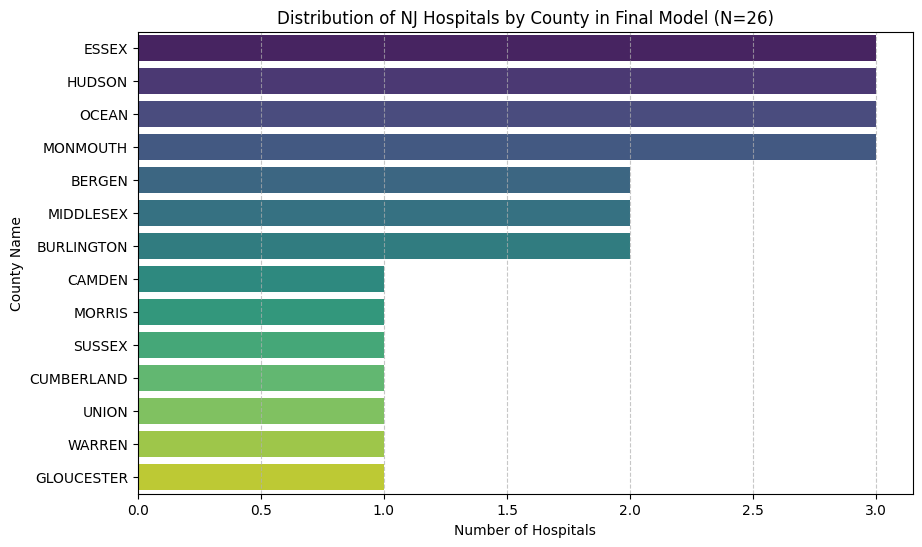

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- DATA QUALITY ANALYSIS ---
# 1. Distribution of Hospitals in the final Modeling set (unified_df)
county_counts = unified_df['County_clean'].value_counts().reset_index()
county_counts.columns = ['County', 'Hospital_Count']

print("--- County Distribution of the 26 Modeling Hospitals ---")
display(county_counts)

# 2. Identify 'Ambiguous' or Mismatched data from the earlier 'merged' step
# We filter the 'merged' dataframe for NJ hospitals that didn't make it into the final lambda calculation
ambiguous_counties = merged[merged['lambda_per_hour'].isna()][['Hospital Name', 'County_clean']]

print("\n--- Hospitals with Missing/Ambiguous County Data (Excluded from Model) ---")
# This highlights hospitals that failed due to 'U.S.A' or NaN county fields in the Cost Report
display(ambiguous_counties)

# 3. Visualization of represented counties
plt.figure(figsize=(10, 6))
sns.barplot(data=county_counts, x='Hospital_Count', y='County', palette='viridis')
plt.title('Distribution of NJ Hospitals by County in Final Model (N=26)')
plt.xlabel('Number of Hospitals')
plt.ylabel('County Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import math

# --- CELL 5: FORWARD M/M/c FORMULAS ---
# μ = 2.55 (EDBA benchmark): baseline productivity in patients per hour
MU_SERVICE_RATE = 2.55

def get_p0(lam, mu, c):
    """Probability that the system is idle (0 patients)."""
    rho = lam / (c * mu)
    term1 = sum([( (lam/mu)**n ) / math.factorial(n) for n in range(int(math.floor(c)))])
    term2 = ( (lam/mu)**c ) / (math.gamma(c + 1) * (1 - rho))
    return 1.0 / (term1 + term2)

def get_erlang_c(lam, mu, c):
    """Probability that an arriving patient must wait (P_wait)."""
    rho = lam / (c * mu)
    p0 = get_p0(lam, mu, c)
    return ( ( (lam/mu)**c ) / (math.gamma(c + 1) * (1 - rho)) ) * p0

def calculate_wq_theoretical(c, lam, mu):
    """Expected waiting time in queue (Wq) in hours."""
    if lam >= (c * mu):
        return np.inf # Unstable: arrival rate exceeds service capacity
    p_wait = get_erlang_c(lam, mu, c)
    return p_wait / (c * mu - lam)

In [ ]:
from scipy.optimize import brentq

# --- CELL 6: INVERSION LOGIC (SOLVING FOR c) ---
def solve_implied_c(lam, wq_obs, mu):
    """
    Finds the root 'c' where Wq_theoretical(c) matches the observed Wq.
    We treat 'c' as continuous for the solver, then round in the final step.
    """
    # Stability constraint: c must be > lambda/mu
    c_min = (lam / mu) + 0.001
    c_max = max(c_min + 150, 250) # Upper bound for search

    def objective(c):
        return calculate_wq_theoretical(c, lam, mu) - wq_obs

    try:
        # Wq(c) is monotonic, so we use Brent's method for root-finding
        return brentq(objective, c_min, c_max)
    except (ValueError, ZeroDivisionError):
        return np.nan # Flags unstable systems where capacity cannot meet observed wait

In [ ]:
from scipy.special import pdtr, gammaln
from scipy.optimize import brentq
import math
import numpy as np

# --- CELL 7: LOG-STABLE INVERSE M/M/c OPTIMIZATION ---
print(f"Analyzing optimization for {len(unified_df)} hospitals using log-stable math...")

def solve_implied_c_robust(lam, wq_obs, mu):
    def objective(c):
        # c must be > lam/mu for stability
        if c <= lam/mu: return 1e9

        rho = lam / (c * mu)
        L = lam / mu

        # Stable calculation of P0 using logarithms to avoid OverflowError
        # Original: term2 = (L**c) / (math.gamma(c+1) * (1-rho))
        # Log version: exp( c*log(L) - loggamma(c+1) - log(1-rho) )
        log_term2 = c * np.log(L) - gammaln(c + 1) - np.log(1 - rho)
        term2 = np.exp(log_term2)

        # term1 uses Poisson CDF (already numerically stable)
        term1 = np.exp(L) * pdtr(int(math.floor(c)) - 1, L)

        p0 = 1.0 / (term1 + term2)
        p_wait = term2 * p0
        wq_theo = p_wait / (c * mu - lam)
        return wq_theo - wq_obs

    c_min = (lam / mu) + 0.01
    c_max = 1000.0 # Increased range, now safe thanks to log-math

    try:
        if objective(c_min) * objective(c_max) > 0:
            return np.nan
        return brentq(objective, c_min, c_max)
    except:
        return np.nan

# Apply the stable solver
unified_df['implied_c'] = unified_df.apply(
    lambda row: solve_implied_c_robust(row['lambda_per_hour'], row['Wq_hours'], MU_SERVICE_RATE),
    axis=1
)

results = unified_df.dropna(subset=['implied_c']).copy()
if len(results) > 0:
    results['implied_c_rounded'] = results['implied_c'].round(2)
    print(f"Successfully solved for {len(results)} hospitals.")
    display(results.sort_values(by='implied_c', ascending=False)[['Facility Name', 'County_clean', 'lambda_per_hour', 'Wq_hours', 'implied_c_rounded']])
else:
    print("\nRESULT: All hospitals failed to converge. Check if Observed Wq is smaller than the model's minimum.")

Analyzing optimization for 25 hospitals using log-stable math...
Successfully solved for 22 hospitals.


,Facility Name,County_clean,lambda_per_hour,Wq_hours,implied_c_rounded
9,INSPIRA MEDICAL CENTER VINELAND,CUMBERLAND,12.192122,3.400000,4.89
19,JERSEY CITY MEDICAL CENTER,HUDSON,11.684947,3.166667,4.70
0,HACKENSACK UNIVERSITY MEDICAL CENTER,BERGEN,9.678187,3.283333,3.91
13,OVERLOOK MEDICAL CENTER,UNION,8.843379,3.200000,3.58
21,COOPERMAN BARNABAS MEDICAL CENTER,ESSEX,8.347449,2.000000,3.45
18,INSPIRA MEDICAL CENTER MULLICA HILL,GLOUCESTER,7.792009,3.033333,3.18
2,PALISADES MEDICAL CENTER,HUDSON,7.172938,3.450000,2.92
12,COMMUNITY MEDICAL CENTER,OCEAN,6.256151,3.033333,2.58
6,MORRISTOWN MEDICAL CENTER,MORRIS,6.027648,4.000000,2.46
14,VIRTUA MOUNT HOLLY HOSPITAL,BURLINGTON,5.957705,3.450000,2.44


In [ ]:
from google.colab import files

# Export the results to a CSV
results_filename = '../data/processed/nj_hospital_implied_capacity_results.csv'
results.to_csv(results_filename, index=False)

print(f"File saved: {results_filename}")
# Trigger a download to your local machine
files.download(results_filename)

File saved: nj_hospital_implied_capacity_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np

# Identify hospitals that were in unified_df but didn't get an implied_c
failed_hospitals = unified_df[unified_df['implied_c'].isna()].copy()

print(f"Analyzing {len(failed_hospitals)} hospitals that failed to converge:\n")

for i, row in failed_hospitals.iterrows():
    l, w, m = row['lambda_per_hour'], row['Wq_hours'], MU_SERVICE_RATE

    # Calculate theoretical wait time at a very high capacity (c=1000)
    # to see the 'floor' of the model for this hospital
    def get_theo_floor(lam, wq_obs, mu, c=1000):
        rho = lam / (c * mu)
        L = lam / mu
        log_term2 = c * np.log(L) - gammaln(c + 1) - np.log(1 - rho)
        term2 = np.exp(log_term2)
        term1 = np.exp(L) * pdtr(int(math.floor(c)) - 1, L)
        p0 = 1.0 / (term1 + term2)
        return (term2 * p0) / (c * mu - lam)

    theo_floor = get_theo_floor(l, w, m)

    print(f"Hospital: {row['Facility Name']}")
    print(f"  Observed Wq: {w:.4f} hours ({w*60:.1f} mins)")
    print(f"  Model Floor: {theo_floor:.4f} hours (even with 1000 doctors)")
    if theo_floor > w:
        print(f"  Reason: Observed wait is shorter than model minimum. Possible underestimation of Lambda.")
    print("-" * 30)

Analyzing 3 hospitals that failed to converge:

Hospital: BERGEN NEW BRIDGE MEDICAL CENTER
  Observed Wq: 2.5667 hours (154.0 mins)
  Model Floor: 0.0000 hours (even with 1000 doctors)
------------------------------
Hospital: ST LUKE'S WARREN HOSPITAL
  Observed Wq: 2.3333 hours (140.0 mins)
  Model Floor: 0.0000 hours (even with 1000 doctors)
------------------------------
Hospital: SOUTHERN OCEAN MEDICAL CENTER
  Observed Wq: 2.7667 hours (166.0 mins)
  Model Floor: 0.0000 hours (even with 1000 doctors)
------------------------------


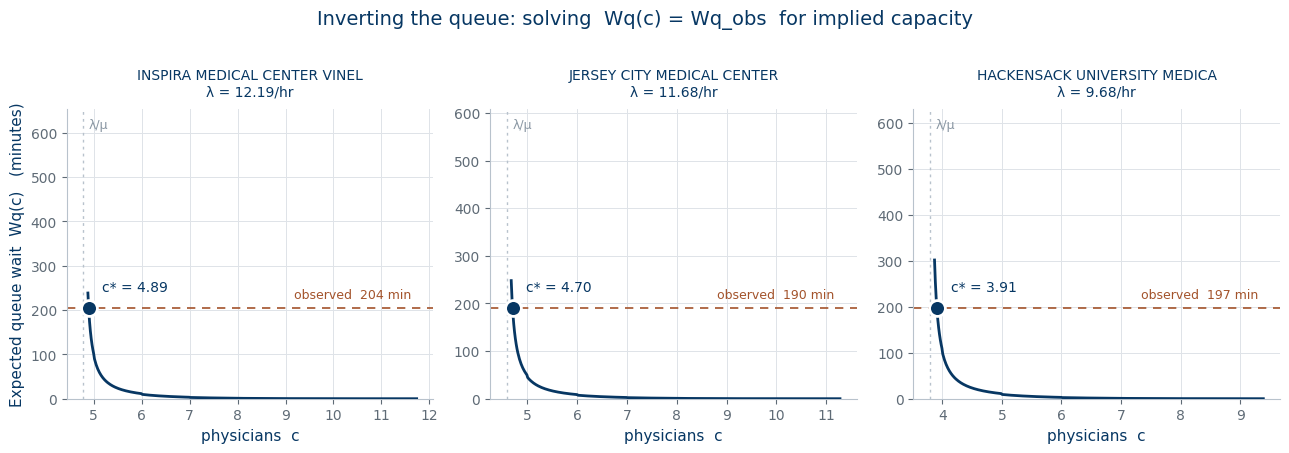

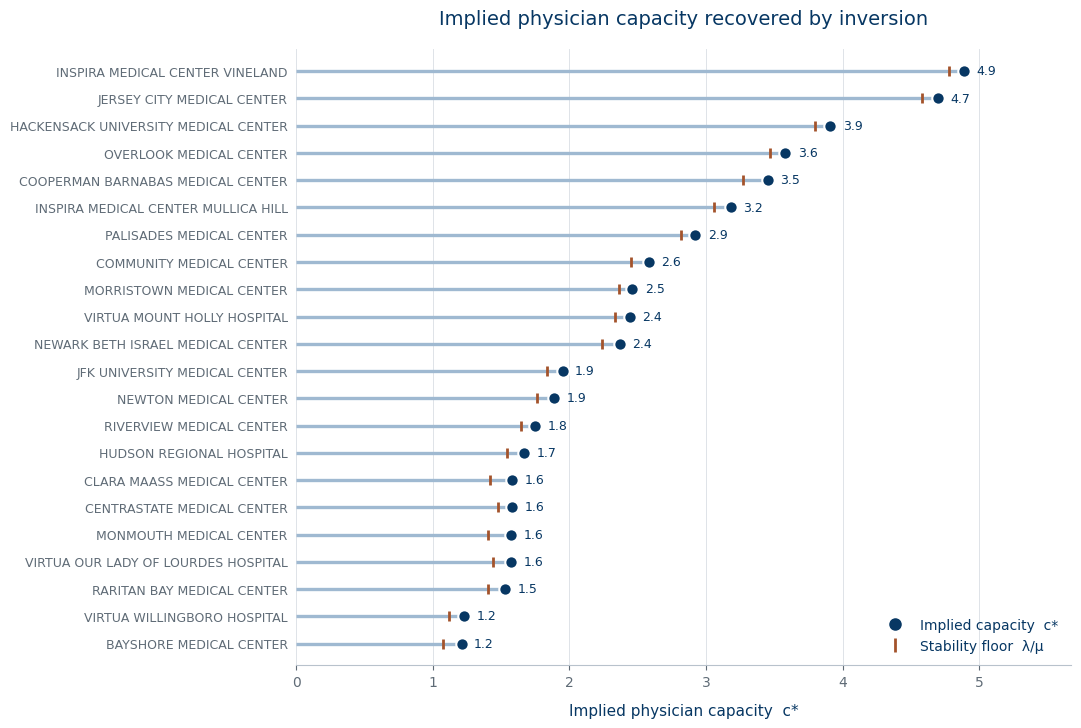

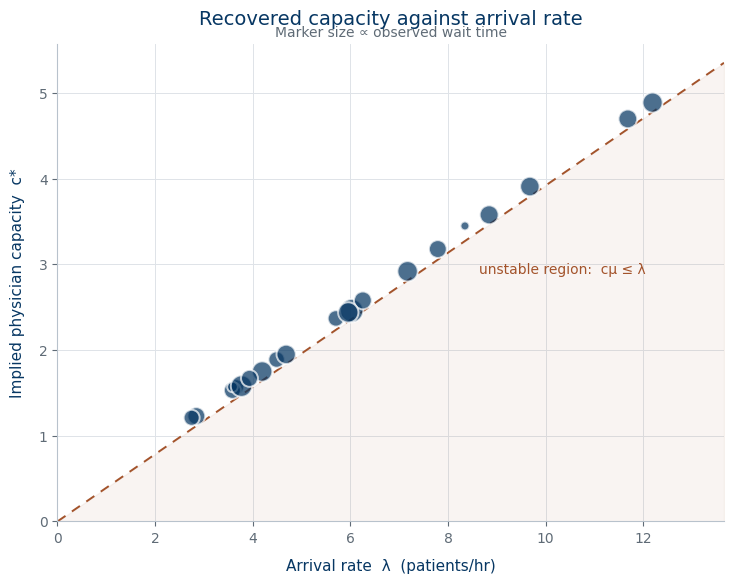

In [ ]:
import numpy as np, math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.special import gammaln, pdtr

MU = MU_SERVICE_RATE
NAVY, LIGHT, ACCENT, GRID, MUTED = "#073763", "#9FB9D1", "#A3532B", "#DFE3E8", "#5F6B76"
plt.rcParams.update({
    "font.family": "DejaVu Sans", "axes.edgecolor": "#B8C2CC", "axes.linewidth": 0.8,
    "axes.labelcolor": NAVY, "text.color": NAVY,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "axes.labelsize": 11,
})

def wq_theo(c, lam, mu=MU):
    if c <= lam / mu: return np.inf
    rho, L = lam / (c * mu), lam / mu
    t2 = np.exp(c*np.log(L) - gammaln(c+1) - np.log(1-rho))
    t1 = np.exp(L) * pdtr(int(math.floor(c))-1, L)
    return (t2 / (t1 + t2)) / (c*mu - lam)

# ---------- FIGURE A: inversion mechanics (3 example hospitals) ----------
sel = results.nlargest(3, "lambda_per_hour").reset_index(drop=True)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (_, r) in zip(axes, sel.iterrows()):
    lam, cs, wobs = r.lambda_per_hour, r.implied_c_rounded, r.Wq_hours
    floor_c = lam / MU
    g = np.linspace(floor_c*1.02, cs*2.4, 400)
    ax.plot(g, [wq_theo(c, lam)*60 for c in g], color=NAVY, lw=2, zorder=3)
    ax.axhline(wobs*60, color=ACCENT, lw=1.2, ls=(0,(5,4)), zorder=2)
    ax.axvline(floor_c, color="#B8C2CC", lw=1.0, ls=(0,(2,3)), zorder=1)
    ax.scatter([cs], [wobs*60], s=130, color=NAVY, edgecolor="white", lw=2, zorder=5)
    ax.annotate(f"c* = {cs:.2f}", xy=(cs, wobs*60), xytext=(10,12),
                textcoords="offset points", fontsize=10, color=NAVY)
    ax.annotate(f"observed  {wobs*60:.0f} min", xy=(g[-1], wobs*60), xytext=(-4,7),
                textcoords="offset points", ha="right", fontsize=9, color=ACCENT)
    ax.set_ylim(0, wobs*60*3.2)
    ax.set_xlabel("physicians  c")
    ax.set_title(f"{r['Facility Name'][:28]}\nλ = {lam:.2f}/hr", fontsize=10, color=NAVY, pad=10)
    ax.annotate("λ/μ", xy=(floor_c, ax.get_ylim()[1]), xytext=(4,-14),
                textcoords="offset points", fontsize=9, color="#8A97A3")
    ax.grid(color=GRID, lw=.7); ax.set_axisbelow(True)
    for s in ("top","right"): ax.spines[s].set_visible(False)
axes[0].set_ylabel("Expected queue wait  Wq(c)   (minutes)")
fig.suptitle("Inverting the queue: solving  Wq(c) = Wq_obs  for implied capacity",
             fontsize=14, color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig("figA_inversion_curves.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# ---------- FIGURE B: implied capacity per facility ----------
d = results.sort_values("implied_c_rounded").reset_index(drop=True)
y = np.arange(len(d))
fig, ax = plt.subplots(figsize=(10, 8))
ax.hlines(y, 0, d.implied_c_rounded, color=LIGHT, lw=2.4, zorder=1)
ax.scatter(d.implied_c_rounded, y, s=80, color=NAVY, edgecolor="white", lw=1.5, zorder=3)
ax.scatter(d.lambda_per_hour/MU, y, s=52, marker="|", color=ACCENT, lw=2, zorder=4)
for i, r in d.iterrows():
    ax.annotate(f"{r.implied_c_rounded:.1f}", xy=(r.implied_c_rounded, i), xytext=(9,0),
                textcoords="offset points", va="center", fontsize=9, color=NAVY)
ax.set_yticks(y); ax.set_yticklabels(d["Facility Name"], fontsize=9)
ax.set_ylim(-0.8, len(d)-0.2); ax.set_xlim(0, d.implied_c_rounded.max()*1.16)
ax.set_xlabel("Implied physician capacity  c*", labelpad=10)
ax.grid(axis="x", color=GRID, lw=.7); ax.set_axisbelow(True)
for s in ("top","right","left"): ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0, pad=6)
ax.legend(handles=[
    Line2D([],[],marker="o",ls="",color=NAVY,ms=8,label="Implied capacity  c*"),
    Line2D([],[],marker="|",ls="",color=ACCENT,ms=10,mew=2,label="Stability floor  λ/μ")],
    loc="lower right", frameon=False, fontsize=10)
ax.set_title("Implied physician capacity recovered by inversion", fontsize=14, color=NAVY, pad=18)
plt.savefig("figB_implied_capacity.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# ---------- FIGURE C: lambda vs implied c, with stability frontier ----------
fig, ax = plt.subplots(figsize=(8.6, 6.2))
lg = np.linspace(0, results.lambda_per_hour.max()*1.12, 100)
ax.plot(lg, lg/MU, color=ACCENT, lw=1.4, ls=(0,(5,4)), zorder=2)
ax.fill_between(lg, 0, lg/MU, color=ACCENT, alpha=.06, zorder=1)
ax.annotate("unstable region:  cμ ≤ λ", xy=(lg[-1]*.62, lg[-1]*.62/MU), xytext=(6,-26),
            textcoords="offset points", fontsize=10, color=ACCENT)
sz = 40 + 240*(results.Wq_hours - results.Wq_hours.min()) / \
     (results.Wq_hours.max() - results.Wq_hours.min())
ax.scatter(results.lambda_per_hour, results.implied_c_rounded, s=sz, color=NAVY,
           alpha=.72, edgecolor="white", lw=1.4, zorder=4)
ax.set_xlabel("Arrival rate  λ  (patients/hr)", labelpad=10)
ax.set_ylabel("Implied physician capacity  c*", labelpad=10)
ax.set_xlim(0, results.lambda_per_hour.max()*1.12)
ax.set_ylim(0, results.implied_c_rounded.max()*1.14)
ax.grid(color=GRID, lw=.7); ax.set_axisbelow(True)
for s in ("top","right"): ax.spines[s].set_visible(False)
ax.set_title("Recovered capacity against arrival rate", fontsize=14, color=NAVY, pad=14)
ax.annotate("Marker size ∝ observed wait time", xy=(0.5,1.015), xycoords="axes fraction",
            ha="center", fontsize=10, color=MUTED)
plt.savefig("figC_lambda_vs_c.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Prompt for Claude: Data Structure Explanation

Copy and paste this to Claude along with your CSV file:

> I am providing a CSV of NJ hospital capacity models. We used an M/M/c queuing model to back-calculate the 'implied capacity' (number of service units) for each hospital.
>
> **CSV Structure:**
> * `Facility Name`: Name of the hospital.
> * `County_clean`: The NJ county where it is located.
> * `Wq_hours`: The target wait time in hours (from CMS data).
> * `lambda_per_hour` ($λ$): The estimated arrival rate (patients/hour).
> * `implied_c`: The raw continuous value for capacity solved by the root-finder.
> * `implied_c_rounded`: The suggested integer/rounded capacity ($c$).
>
> **Modeling Context:**
> These results assume a service rate ($μ$) of **2.55 patients/hour**. The system is stable only when $c \cdot \mu > \lambda$. Use this data to implement the greedy optimization for SVI-weighted resource allocation.

### Mathematical Formula for Root-Finding
The optimization solves for $c$ in the following system:

1. **Utilization**: $\rho = \frac{\lambda}{c\mu}$
2. **Erlang C (Probability of Waiting)**:
   $$C(c, \lambda/\mu) = \frac{\frac{(\lambda/\mu)^c}{c! (1-\rho)}}{\sum_{k=0}^{c-1} \frac{(\lambda/\mu)^k}{k!} + \frac{(\lambda/\mu)^c}{c! (1-\rho)}}$$
3. **Expected Wait Time in Queue**:
   $$W_q = \frac{C(c, \lambda/\mu)}{c\mu - \lambda}$$

Cell 7 uses `scipy.special.gammaln` and `pdtr` to solve this for $c$ while avoiding numerical overflow.